In [1]:
import pandas as pd
import numpy as np

orders = pd.read_csv('/Users/nitesh/Downloads/Task 1/olist_orders_dataset.csv')

print(orders.head())
print(orders.shape)
print(orders.info())

                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08

In [2]:
# Checking data Quality

In [3]:
print(orders.isnull().sum())
print("Duplicate rows:", orders.duplicated().sum())
print(orders.dtypes)

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
Duplicate rows: 0
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object


An initial quality assessment was performed using Pandas to identify missing values, duplicate records, and data types. No duplicate rows were found in the dataset. Missing values were identified in the order approval, carrier delivery, and customer delivery timestamp fields. The customer delivery timestamp contained the highest number of missing values, with 2,965 records. All timestamp fields were initially stored as object/string data types and therefore required conversion to datetime format before performing delivery-time calculations.

In [4]:
# Convert the dates 

In [5]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

print(orders[date_cols].dtypes)

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


All five timestamp columns are now correctly converted from object to datetime64[ns].

In [6]:
# Understanding the missing dates 

In [7]:
print(
    orders.groupby("order_status")[
        [
            "order_approved_at",
            "order_delivered_carrier_date",
            "order_delivered_customer_date"
        ]
    ].apply(lambda x: x.isna().sum())
)

              order_approved_at  order_delivered_carrier_date  \
order_status                                                    
approved                      0                             2   
canceled                    141                           550   
created                       5                             5   
delivered                    14                             2   
invoiced                      0                           314   
processing                    0                           301   
shipped                       0                             0   
unavailable                   0                           609   

              order_delivered_customer_date  
order_status                                 
approved                                  2  
canceled                                619  
created                                   5  
delivered                                 8  
invoiced                                314  
processing                 

In [8]:
print("Delivered orders:", (orders["order_status"] == "delivered").sum())

print(
    "Delivered orders with missing customer delivery date:",
    orders.loc[
        orders["order_status"] == "delivered",
        "order_delivered_customer_date"
    ].isna().sum()
)

print(
    "Delivered orders with missing purchase date:",
    orders.loc[
        orders["order_status"] == "delivered",
        "order_purchase_timestamp"
    ].isna().sum()
)

print(
    "Delivered orders with missing estimated date:",
    orders.loc[
        orders["order_status"] == "delivered",
        "order_estimated_delivery_date"
    ].isna().sum()
)

Delivered orders: 96478
Delivered orders with missing customer delivery date: 8
Delivered orders with missing purchase date: 0
Delivered orders with missing estimated date: 0


In [9]:
# Create the delivery-analysis dataset

In [10]:
delivery_orders = orders[
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_customer_date"].notna())
].copy()

print("Delivery analysis records:", len(delivery_orders))
print(delivery_orders.isna().sum())

Delivery analysis records: 96470
order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      1
order_delivered_customer_date     0
order_estimated_delivery_date     0
dtype: int64


In [11]:
# Actual Delivery dates 

In [12]:
delivery_orders["actual_delivery_days"] = (
    delivery_orders["order_delivered_customer_date"]
    - delivery_orders["order_purchase_timestamp"]
).dt.days

print(delivery_orders["actual_delivery_days"].describe())

count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: actual_delivery_days, dtype: float64


In [13]:
# Estimated delivary days 

In [14]:
delivery_orders["estimated_delivery_days"] = (
    delivery_orders["order_estimated_delivery_date"]
    - delivery_orders["order_purchase_timestamp"]
).dt.days

print(delivery_orders["estimated_delivery_days"].describe())

count    96470.000000
mean        23.372748
std          8.758421
min          2.000000
25%         18.000000
50%         23.000000
75%         28.000000
max        155.000000
Name: estimated_delivery_days, dtype: float64


In [15]:
# Delay days 

In [16]:
delivery_orders["delay_days"] = (
    delivery_orders["actual_delivery_days"]
    - delivery_orders["estimated_delivery_days"]
)

print(delivery_orders["delay_days"].describe())

count    96470.000000
mean       -11.279144
std         10.192137
min       -146.000000
25%        -16.000000
50%        -12.000000
75%         -7.000000
max        189.000000
Name: delay_days, dtype: float64


In [17]:
# Delivary Performance 

In [18]:
delivery_orders["delivery_performance"] = delivery_orders[
    "delay_days"
].apply(
    lambda x: "Delayed" if x > 0 else "On Time"
)

print(delivery_orders["delivery_performance"].value_counts())

delivery_performance
On Time    89163
Delayed     7307
Name: count, dtype: int64


##### The average difference between actual and estimated delivery duration was -11.28 days, indicating that deliveries were generally completed earlier than the estimated date.

## Detect outliers using IQR

In [19]:
q1 = delivery_orders["actual_delivery_days"].quantile(0.25)
q3 = delivery_orders["actual_delivery_days"].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 6.0
Q3: 15.0
IQR: 9.0
Lower bound: -7.5
Upper bound: 28.5


In [20]:
outliers = delivery_orders[
    (delivery_orders["actual_delivery_days"] < lower_bound) |
    (delivery_orders["actual_delivery_days"] > upper_bound)
]

print("Number of outliers:", len(outliers))
print("Percentage of outliers:", len(outliers) / len(delivery_orders) * 100)

Number of outliers: 5022
Percentage of outliers: 5.205763449777133


In [21]:
print(outliers["actual_delivery_days"].describe())

count    5022.000000
mean       40.047591
std        16.104355
min        29.000000
25%        31.000000
50%        36.000000
75%        43.000000
max       209.000000
Name: actual_delivery_days, dtype: float64


In [22]:
print(
    "Negative actual delivery days:",
    (delivery_orders["actual_delivery_days"] < 0).sum()
)

print(
    "Zero-day deliveries:",
    (delivery_orders["actual_delivery_days"] == 0).sum()
)

Negative actual delivery days: 0
Zero-day deliveries: 13


In [23]:
# Creating flag for outliers 

In [24]:
delivery_orders["delivery_time_outlier"] = delivery_orders[
    "actual_delivery_days"
].apply(
    lambda x: "Outlier" if x > upper_bound else "Normal"
)

print(
    delivery_orders["delivery_time_outlier"].value_counts()
)

delivery_time_outlier
Normal     91448
Outlier     5022
Name: count, dtype: int64


Outlier Treatment: The Interquartile Range (IQR) method was used to identify unusually long delivery durations. The first quartile was 6 days and the third quartile was 15 days, resulting in an IQR of 9 days and an upper outlier threshold of 28.5 days. A total of 5,022 records (5.21%) were identified as outliers. These records were not removed because unusually long deliveries may represent genuine logistics delays or operational issues. Instead, an outlier flag was created so that these observations can be investigated separately during subsequent analysis.

In [25]:
# Min-Max normalization

In [26]:
min_delivery = delivery_orders["actual_delivery_days"].min()
max_delivery = delivery_orders["actual_delivery_days"].max()

delivery_orders["actual_delivery_days_normalized"] = (
    (delivery_orders["actual_delivery_days"] - min_delivery)
    / (max_delivery - min_delivery)
)

print(
    delivery_orders[
        [
            "actual_delivery_days",
            "actual_delivery_days_normalized"
        ]
    ].head()
)

   actual_delivery_days  actual_delivery_days_normalized
0                     8                         0.038278
1                    13                         0.062201
2                     9                         0.043062
3                    13                         0.062201
4                     2                         0.009569


In [27]:
print(
    "Normalized minimum:",
    delivery_orders["actual_delivery_days_normalized"].min()
)

print(
    "Normalized maximum:",
    delivery_orders["actual_delivery_days_normalized"].max()
)

Normalized minimum: 0.0
Normalized maximum: 1.0


Normalization: Min-Max normalization was applied to the actual delivery duration feature. The transformation scales delivery duration to a range between 0 and 1 using the minimum and maximum observed delivery times. This creates a standardized numerical representation that can be useful for comparison and future machine-learning applications. The identified outliers were retained because they may represent genuine logistics events rather than erroneous observations.

In [28]:
# FINAL VALIDATION

In [29]:
print("========== FINAL VALIDATION ==========")

print("Final records:", len(delivery_orders))

print(
    "Duplicate rows:",
    delivery_orders.duplicated().sum()
)

print("\nMissing values:")
print(delivery_orders.isna().sum())

print(
    "\nNegative delivery days:",
    (delivery_orders["actual_delivery_days"] < 0).sum()
)

print(
    "\nOutlier records:",
    (delivery_orders["delivery_time_outlier"] == "Outlier").sum()
)

print(
    "\nDelivery performance:"
)
print(delivery_orders["delivery_performance"].value_counts())

print(
    "\nNormalized range:",
    delivery_orders["actual_delivery_days_normalized"].min(),
    "to",
    delivery_orders["actual_delivery_days_normalized"].max()
)

========== FINAL VALIDATION ==========
Final records: 96470
Duplicate rows: 0

Missing values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  14
order_delivered_carrier_date        1
order_delivered_customer_date       0
order_estimated_delivery_date       0
actual_delivery_days                0
estimated_delivery_days             0
delay_days                          0
delivery_performance                0
delivery_time_outlier               0
actual_delivery_days_normalized     0
dtype: int64

Negative delivery days: 0

Outlier records: 5022

Delivery performance:
delivery_performance
On Time    89163
Delayed     7307
Name: count, dtype: int64

Normalized range: 0.0 to 1.0


In [30]:
# Saving Clean Dataset 

In [31]:
delivery_orders.to_csv(
    "logistics_delivery_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


##### All critical fields required for delivery-time analysis were complete. Fifteen missing values remained in non-critical operational timestamp fields (order_approved_at and order_delivered_carrier_date), and these records were retained because they did not affect the delivery-time calculations.

# Task 03 – Advanced Data Analysis and Visualization in Logistics

## Objective

This analysis focuses on exploring logistics delivery performance, identifying operational patterns, understanding cost and time-related factors, and presenting the findings through meaningful visualizations.

The analysis builds on the cleaned logistics order data prepared in the previous stage.

## Data Preparation

In [32]:
# Task 03 – Data Preparation

# Create a working copy of the cleaned dataset
analysis_df = delivery_orders.copy()

# Display dataset structure
print("Dataset shape:", analysis_df.shape)
print("\nColumns:")
print(analysis_df.columns.tolist())

# Display first five records
analysis_df.head()

Dataset shape: (96470, 14)

Columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'actual_delivery_days', 'estimated_delivery_days', 'delay_days', 'delivery_performance', 'delivery_time_outlier', 'actual_delivery_days_normalized']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,actual_delivery_days,estimated_delivery_days,delay_days,delivery_performance,delivery_time_outlier,actual_delivery_days_normalized
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,15,-7,On Time,Normal,0.038278
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13,19,-6,On Time,Normal,0.062201
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9,26,-17,On Time,Normal,0.043062
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13,26,-13,On Time,Normal,0.062201
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2,12,-10,On Time,Normal,0.009569


## Descriptive Statistics

In [33]:
# Task 03 – Descriptive Statistics

# Select key numerical logistics metrics
numeric_metrics = [
    'actual_delivery_days',
    'estimated_delivery_days',
    'delay_days'
]

# Calculate descriptive statistics
descriptive_stats = analysis_df[numeric_metrics].describe().T

# Add median separately
descriptive_stats['median'] = analysis_df[numeric_metrics].median()

# Display results
descriptive_stats

,count,mean,std,min,25%,50%,75%,max,median
actual_delivery_days,96470.0,12.093604,9.551380,0.0,6.0,10.0,15.0,209.0,10.0
estimated_delivery_days,96470.0,23.372748,8.758421,2.0,18.0,23.0,28.0,155.0,23.0
delay_days,96470.0,-11.279144,10.192137,-146.0,-16.0,-12.0,-7.0,189.0,-12.0


## Distribution Analysis

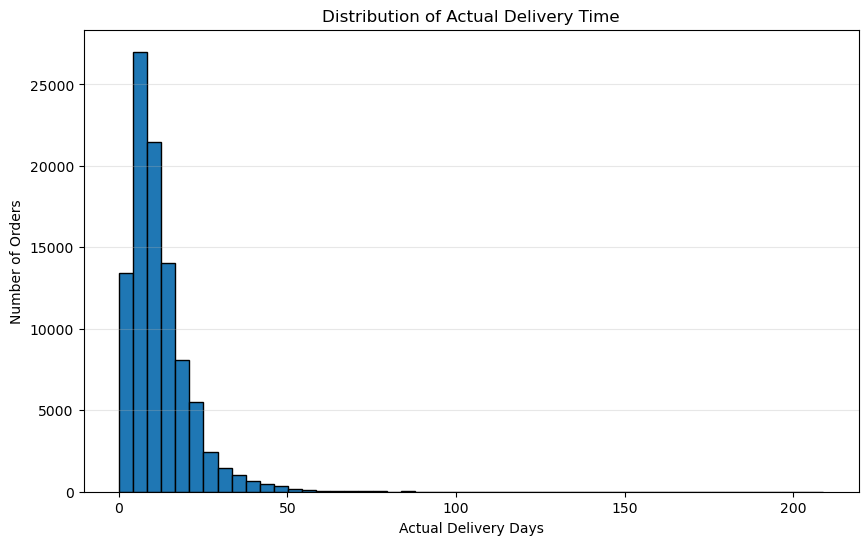

In [34]:
# Task 03 – Distribution Analysis

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    analysis_df['actual_delivery_days'],
    bins=50,
    edgecolor='black'
)

plt.title('Distribution of Actual Delivery Time')
plt.xlabel('Actual Delivery Days')
plt.ylabel('Number of Orders')
plt.grid(axis='y', alpha=0.3)

plt.show()

### Actual Delivery Time Distribution:
The distribution of actual delivery time is highly right-skewed, indicating that the majority of orders were delivered within a relatively short period, primarily between 5 and 20 days. A small number of orders experienced significantly longer delivery times, creating a long right tail extending beyond 100 days. These extreme delivery durations may indicate exceptional delays or potential data-quality issues and should be investigated separately.

## Outlier Analysis

In [39]:
# Convert date columns to datetime
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

orders['order_delivered_customer_date'] = pd.to_datetime(
    orders['order_delivered_customer_date']
)

# Calculate actual delivery time in days
orders['actual_delivery_days'] = (
    orders['order_delivered_customer_date']
    - orders['order_purchase_timestamp']
).dt.total_seconds() / (24 * 60 * 60)

# Check the result
orders[['order_purchase_timestamp',
        'order_delivered_customer_date',
        'actual_delivery_days']].head()

,order_purchase_timestamp,order_delivered_customer_date,actual_delivery_days
0,2017-10-02 10:56:33,2017-10-10 21:25:13,8.436574
1,2018-07-24 20:41:37,2018-08-07 15:27:45,13.782037
2,2018-08-08 08:38:49,2018-08-17 18:06:29,9.394213
3,2017-11-18 19:28:06,2017-12-02 00:28:42,13.208750
4,2018-02-13 21:18:39,2018-02-16 18:17:02,2.873877


In [40]:
orders['actual_delivery_days'].describe()

count    96476.000000
mean        12.558702
std          9.546530
min          0.533414
25%          6.766403
50%         10.217755
75%         15.720327
max        209.628611
Name: actual_delivery_days, dtype: float64

In [41]:
outliers[
    [
        'order_id',
        'customer_id',
        'order_purchase_timestamp',
        'order_delivered_customer_date',
        'actual_delivery_days'
    ]
].sort_values(
    'actual_delivery_days',
    ascending=False
).head(20)

,order_id,customer_id,order_purchase_timestamp,order_delivered_customer_date,actual_delivery_days
19590,ca07593549f1816d26a572e06dc1eab6,75683a92331068e2d281b11a7866ba44,2017-02-21 23:31:27,2017-09-19 14:36:39,209
55619,1b3190b2dfa9d789e1f14c05b647a14a,d306426abe5fca15e54b645e4462dc7b,2018-02-23 14:57:35,2018-09-19 23:24:07,208
61610,440d0d17af552815d15a9e41abe49359,7815125148cfa1e8c7fee1ff7974f16c,2017-03-07 23:59:51,2017-09-19 15:12:50,195
89130,285ab9426d6982034523a855f55a885e,9cf2c3fa2632cee748e1a59ca9d09b21,2017-03-08 22:47:40,2017-09-19 14:00:04,194
38509,0f4519c5f1c541ddec9f21b3bddd533a,1a8a4a30dc296976717f44e7801fdeef,2017-03-09 13:26:57,2017-09-19 14:38:21,194
70307,2fb597c2f772eca01b1f5c561bf6cc7b,217906bc11a32c1e470eb7e08584894b,2017-03-08 18:09:02,2017-09-19 14:33:17,194
11399,47b40429ed8cce3aee9199792275433f,cb2caaaead400c97350c37a3fc536867,2018-01-03 09:44:01,2018-07-13 20:51:31,191
81401,2fe324febf907e3ea3f2aa9650869fa5,65b14237885b3972ebec28c0f7dd2220,2017-03-13 20:17:10,2017-09-19 17:00:07,189
54480,2d7561026d542c8dbd8f0daeadf67a43,8199345f57c6d1cbe9701f92481beb8d,2017-03-15 11:24:27,2017-09-19 14:38:18,188
68769,c27815f7e3dd0b926b58552628481575,f85e9ec0719b16dc4dd0edd438793553,2017-03-15 23:23:17,2017-09-19 17:14:25,187


In [42]:
Q1 = orders['actual_delivery_days'].quantile(0.25)
Q3 = orders['actual_delivery_days'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 6.766403356481481
Q3: 15.720326967592593
IQR: 8.953923611111112
Lower Bound: -6.664482060185186
Upper Bound: 29.15121238425926


In [43]:
outliers = orders[
    (orders['actual_delivery_days'] < lower_bound) |
    (orders['actual_delivery_days'] > upper_bound)
]

print("Number of outliers:", len(outliers))
print("Percentage of outliers:", len(outliers) / len(orders) * 100)

Number of outliers: 4899
Percentage of outliers: 4.926539354994419


In [44]:
orders['delivery_time_outlier'] = (
    orders['actual_delivery_days'] > upper_bound
)

orders['delivery_time_outlier'].value_counts()

delivery_time_outlier
False    94542
True      4899
Name: count, dtype: int64

## Analyze normal vs. outlier delivery time

In [45]:
orders.groupby('delivery_time_outlier')['actual_delivery_days'].describe()

,count,mean,std,min,25%,50%,75%,max
delivery_time_outlier,,,,,,,,
False,91577.0,11.048780,6.088342,0.533414,6.467350,9.911042,14.518241,29.149572
True,4899.0,40.783683,16.205274,29.153322,32.142616,36.153600,43.724716,209.628611


### Checking the extreme delays

In [46]:
outliers[['order_id',
          'customer_id',
          'order_purchase_timestamp',
          'order_delivered_customer_date',
          'actual_delivery_days']].sort_values(
    'actual_delivery_days',
    ascending=False
).head(20)

,order_id,customer_id,order_purchase_timestamp,order_delivered_customer_date,actual_delivery_days
19590,ca07593549f1816d26a572e06dc1eab6,75683a92331068e2d281b11a7866ba44,2017-02-21 23:31:27,2017-09-19 14:36:39,209.628611
55619,1b3190b2dfa9d789e1f14c05b647a14a,d306426abe5fca15e54b645e4462dc7b,2018-02-23 14:57:35,2018-09-19 23:24:07,208.351759
61610,440d0d17af552815d15a9e41abe49359,7815125148cfa1e8c7fee1ff7974f16c,2017-03-07 23:59:51,2017-09-19 15:12:50,195.634016
70307,2fb597c2f772eca01b1f5c561bf6cc7b,217906bc11a32c1e470eb7e08584894b,2017-03-08 18:09:02,2017-09-19 14:33:17,194.850174
89130,285ab9426d6982034523a855f55a885e,9cf2c3fa2632cee748e1a59ca9d09b21,2017-03-08 22:47:40,2017-09-19 14:00:04,194.633611
38509,0f4519c5f1c541ddec9f21b3bddd533a,1a8a4a30dc296976717f44e7801fdeef,2017-03-09 13:26:57,2017-09-19 14:38:21,194.049583
11399,47b40429ed8cce3aee9199792275433f,cb2caaaead400c97350c37a3fc536867,2018-01-03 09:44:01,2018-07-13 20:51:31,191.463542
81401,2fe324febf907e3ea3f2aa9650869fa5,65b14237885b3972ebec28c0f7dd2220,2017-03-13 20:17:10,2017-09-19 17:00:07,189.863160
54480,2d7561026d542c8dbd8f0daeadf67a43,8199345f57c6d1cbe9701f92481beb8d,2017-03-15 11:24:27,2017-09-19 14:38:18,188.134618
68769,c27815f7e3dd0b926b58552628481575,f85e9ec0719b16dc4dd0edd438793553,2017-03-15 23:23:17,2017-09-19 17:14:25,187.743843


### Check how many extreme orders there are

In [47]:
orders['delivery_delay_category'] = pd.cut(
    orders['actual_delivery_days'],
    bins=[0, 15, 30, 60, 100, float('inf')],
    labels=['0-15 days', '16-30 days', '31-60 days', '61-100 days', '100+ days']
)

orders['delivery_delay_category'].value_counts().sort_index()

delivery_delay_category
0-15 days      70096
16-30 days     21827
31-60 days      4247
61-100 days      242
100+ days         64
Name: count, dtype: int64

In [48]:
orders.groupby('delivery_time_outlier')['actual_delivery_days'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

,count,mean,median,min,max
delivery_time_outlier,,,,,
False,91577,11.048780,9.911042,0.533414,29.149572
True,4899,40.783683,36.153600,29.153322,209.628611


### Outlier Analysis:
The IQR method was used to identify unusually long delivery durations. The first quartile (Q1) was 6.77 days and the third quartile (Q3) was 15.72 days, resulting in an IQR of 8.95 days. The upper outlier threshold was calculated as 29.15 days. A total of 4,899 orders (approximately 4.93% of orders with valid delivery durations) were identified as outliers.

Normal deliveries had a median delivery time of approximately 9.91 days, while outlier deliveries had a much higher median of approximately 36.15 days. The most extreme delivery duration was approximately 209.63 days.

These records were not removed, as long delivery times may represent genuine operational delays and are relevant to logistics performance analysis. Instead, they were flagged using delivery_time_outlier for further investigation.

#### Convert estimated date

In [49]:
orders['order_estimated_delivery_date'] = pd.to_datetime(
    orders['order_estimated_delivery_date']
)

#### Calculate delivery delay

In [50]:
orders['delivery_delay_days'] = (
    orders['order_delivered_customer_date']
    - orders['order_estimated_delivery_date']
).dt.total_seconds() / (24 * 60 * 60)

#### Create delivery status

In [51]:
orders['delivery_status'] = orders['delivery_delay_days'].apply(
    lambda x: 'Late' if x > 0 else 'On Time'
)

#### Check the result

In [52]:
orders[['order_estimated_delivery_date',
        'order_delivered_customer_date',
        'delivery_delay_days',
        'delivery_status']].head()

,order_estimated_delivery_date,order_delivered_customer_date,delivery_delay_days,delivery_status
0,2017-10-18,2017-10-10 21:25:13,-7.107488,On Time
1,2018-08-13,2018-08-07 15:27:45,-5.355729,On Time
2,2018-09-04,2018-08-17 18:06:29,-17.245498,On Time
3,2017-12-15,2017-12-02 00:28:42,-12.980069,On Time
4,2018-02-26,2018-02-16 18:17:02,-9.238171,On Time


In [53]:
orders['delivery_status'].value_counts()

delivery_status
On Time    91614
Late        7827
Name: count, dtype: int64

#### Fix the delivery status

In [54]:
orders['delivery_status'] = orders['delivery_delay_days'].apply(
    lambda x: 'Unknown' if pd.isna(x)
    else 'Late' if x > 0
    else 'On Time'
)

#### Check the corrected counts

In [55]:
orders['delivery_status'].value_counts()

delivery_status
On Time    88649
Late        7827
Unknown     2965
Name: count, dtype: int64

#### Check the actual delay statistics

In [56]:
orders['delivery_delay_days'].describe()

count    96476.000000
mean       -11.179120
std         10.186113
min       -146.016123
25%        -16.244384
50%        -11.948941
75%         -6.390000
max        188.975081
Name: delivery_delay_days, dtype: float64

In [57]:
orders.loc[
    orders['delivery_status'] == 'Late',
    'delivery_delay_days'
].describe()

count    7827.000000
mean        9.552206
std        13.951700
min         0.002500
25%         1.867193
50%         5.807894
75%        11.822471
max       188.975081
Name: delivery_delay_days, dtype: float64

### Analyze Delivery Delay Categories

In [58]:
orders['delivery_delay_category'] = pd.cut(
    orders['delivery_delay_days'],
    bins=[-float('inf'), 0, 7, 15, 30, float('inf')],
    labels=[
        'On Time / Early',
        'Late 1-7 days',
        'Late 8-15 days',
        'Late 16-30 days',
        'Late 30+ days'
    ]
)

In [59]:
orders['delivery_delay_category'].value_counts()

delivery_delay_category
On Time / Early    88649
Late 1-7 days       4481
Late 8-15 days      1962
Late 16-30 days     1024
Late 30+ days        360
Name: count, dtype: int64

In [60]:
orders['delivery_delay_category'].value_counts(normalize=True) * 100

delivery_delay_category
On Time / Early    91.887101
Late 1-7 days       4.644678
Late 8-15 days      2.033666
Late 16-30 days     1.061404
Late 30+ days       0.373150
Name: proportion, dtype: float64

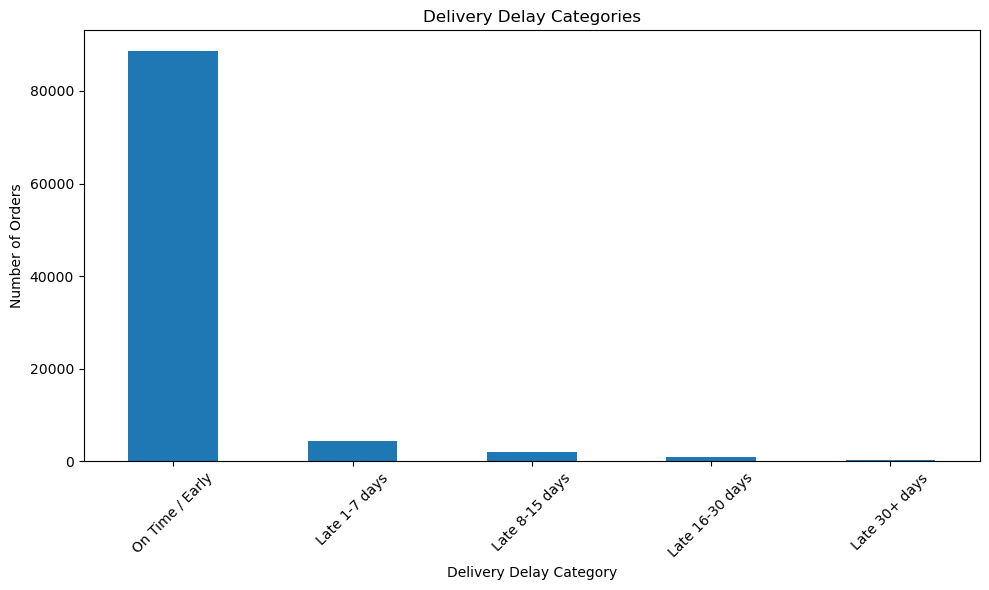

In [62]:
import matplotlib.pyplot as plt

orders['delivery_delay_category'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Delivery Delay Categories')
plt.xlabel('Delivery Delay Category')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Delivery delay analysis showed that the majority of orders were delivered on time or earlier than the estimated delivery date. Among delayed orders, most delays were within 1–7 days, while progressively fewer orders experienced delays of 8–15, 16–30, or more than 30 days. This indicates that severe delivery delays were relatively uncommon but should be investigated separately.

In [63]:
orders['delivery_delay_category'].value_counts(dropna=False)

delivery_delay_category
On Time / Early    88649
Late 1-7 days       4481
NaN                 2965
Late 8-15 days      1962
Late 16-30 days     1024
Late 30+ days        360
Name: count, dtype: int64

In [64]:
orders['delivery_delay_category'].value_counts(normalize=True, dropna=False) * 100

delivery_delay_category
On Time / Early    89.147334
Late 1-7 days       4.506190
NaN                 2.981668
Late 8-15 days      1.973029
Late 16-30 days     1.029756
Late 30+ days       0.362024
Name: proportion, dtype: float64

### Delivery performance over time.

Creating year and month

In [65]:
# Extract year and month from purchase timestamp
orders['purchase_year'] = orders['order_purchase_timestamp'].dt.year
orders['purchase_month'] = orders['order_purchase_timestamp'].dt.month

# Create year-month for monthly trend analysis
orders['purchase_year_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

orders[['order_purchase_timestamp', 
        'purchase_year', 
        'purchase_month', 
        'purchase_year_month']].head()

,order_purchase_timestamp,purchase_year,purchase_month,purchase_year_month
0,2017-10-02 10:56:33,2017,10,2017-10
1,2018-07-24 20:41:37,2018,7,2018-07
2,2018-08-08 08:38:49,2018,8,2018-08
3,2017-11-18 19:28:06,2017,11,2017-11
4,2018-02-13 21:18:39,2018,2,2018-02


Analyzing monthly delivery performance

In [66]:
monthly_delivery = orders.groupby('purchase_year_month').agg(
    total_orders=('order_id', 'count'),
    avg_delivery_days=('actual_delivery_days', 'mean'),
    avg_delay_days=('delivery_delay_days', 'mean')
).reset_index()

monthly_delivery.head(10)

,purchase_year_month,total_orders,avg_delivery_days,avg_delay_days
0,2016-09,4,54.813194,36.324745
1,2016-10,324,19.578572,-36.059479
2,2016-12,1,4.693021,-21.336991
3,2017-01,800,12.647044,-26.861788
4,2017-02,1780,13.168825,-18.680104
5,2017-03,2682,12.951184,-11.781202
6,2017-04,2404,14.917913,-12.431898
7,2017-05,3700,11.322363,-12.962421
8,2017-06,3245,12.011573,-12.010292
9,2017-07,4026,11.592732,-11.724584


Calculate monthly late orders

In [67]:
monthly_late = orders.groupby('purchase_year_month').agg(
    total_orders=('order_id', 'count'),
    late_orders=('delivery_status', lambda x: (x == 'Late').sum())
).reset_index()

monthly_late['late_rate'] = (
    monthly_late['late_orders'] /
    monthly_late['total_orders'] * 100
)

monthly_late.head(10)

,purchase_year_month,total_orders,late_orders,late_rate
0,2016-09,4,1,25.000000
1,2016-10,324,3,0.925926
2,2016-12,1,0,0.000000
3,2017-01,800,23,2.875000
4,2017-02,1780,53,2.977528
5,2017-03,2682,142,5.294556
6,2017-04,2404,181,7.529118
7,2017-05,3700,128,3.459459
8,2017-06,3245,121,3.728814
9,2017-07,4026,133,3.303527


Plot the late delivery trend

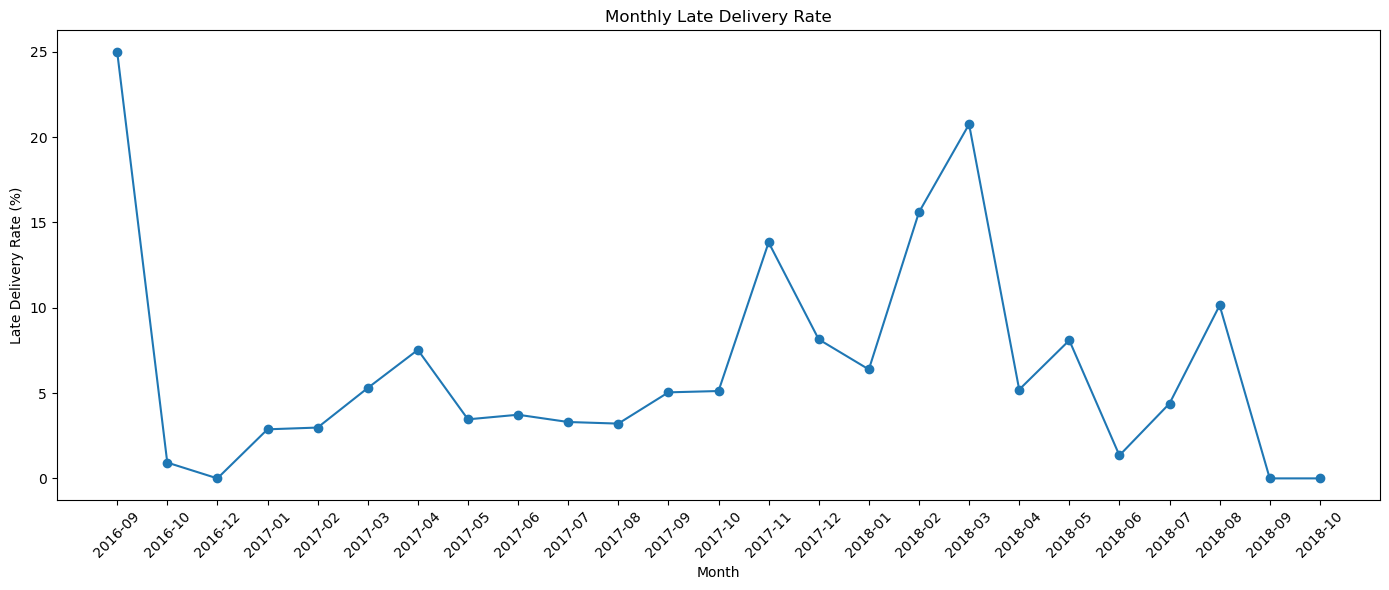

In [68]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_late['purchase_year_month'].astype(str),
    monthly_late['late_rate'],
    marker='o'
)

plt.title('Monthly Late Delivery Rate')
plt.xlabel('Month')
plt.ylabel('Late Delivery Rate (%)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Monthly delivery analysis was performed to identify changes in delivery performance over time. The late-delivery rate was compared across months to identify periods with unusually high delivery delays.

In [69]:
# Final dataset validation

print("========== FINAL VALIDATION ==========")
print("Rows:", len(orders))
print("Columns:", len(orders.columns))

print("\nMissing values:")
print(orders.isnull().sum())

print("\nDuplicate rows:", orders.duplicated().sum())

print("\nData types:")
print(orders.dtypes)

print("\nFinal columns:")
print(orders.columns.tolist())

========== FINAL VALIDATION ==========
Rows: 99441
Columns: 16

Missing values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
actual_delivery_days             2965
delivery_time_outlier               0
delivery_delay_category          2965
delivery_delay_days              2965
delivery_status                     0
purchase_year                       0
purchase_month                      0
purchase_year_month                 0
dtype: int64

Duplicate rows: 0

Data types:
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_dat

In [70]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Saving final clean dataset

In [71]:
# Save final cleaned dataset
orders.to_csv('cleaned_orders.csv', index=False)

print("Cleaned dataset saved successfully.")
print("Rows:", len(orders))
print("Columns:", len(orders.columns))

Cleaned dataset saved successfully.
Rows: 99441
Columns: 16


In [72]:
# ==========================================
# EDA - Central Tendency and Key Statistics
# ==========================================

numeric_cols = [
    'actual_delivery_days',
    'delivery_delay_days'
]

eda_summary = orders[numeric_cols].describe().T

eda_summary['median'] = orders[numeric_cols].median()

eda_summary = eda_summary[
    ['count', 'mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max']
]

eda_summary

,count,mean,median,std,min,25%,50%,75%,max
actual_delivery_days,96476.0,12.558702,10.217755,9.546530,0.533414,6.766403,10.217755,15.720327,209.628611
delivery_delay_days,96476.0,-11.179120,-11.948941,10.186113,-146.016123,-16.244384,-11.948941,-6.390000,188.975081


In [73]:
# ==========================================
# Correlation Analysis
# ==========================================

correlation = orders[numeric_cols].corr()

correlation

,actual_delivery_days,delivery_delay_days
actual_delivery_days,1.000000,0.607221
delivery_delay_days,0.607221,1.000000


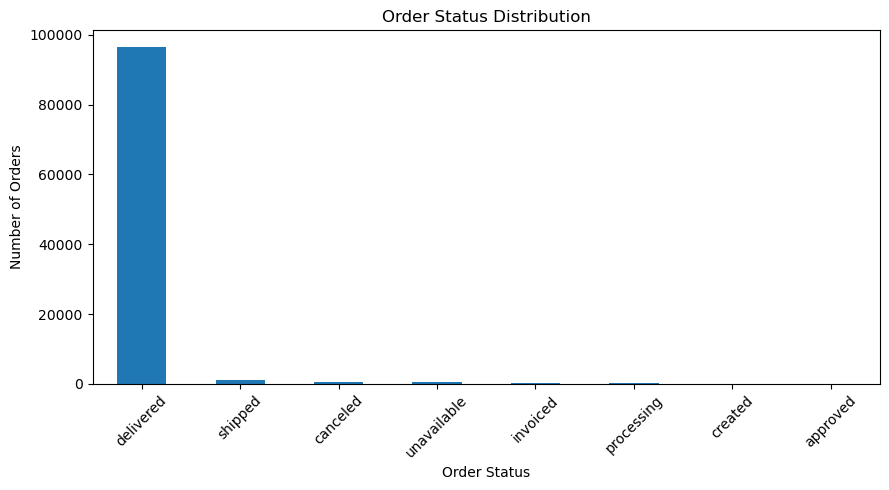

In [74]:
# Order Status Distribution

status_counts = orders['order_status'].value_counts()

plt.figure(figsize=(9,5))
status_counts.plot(kind='bar')

plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Key Insight: 
89.15% of orders were delivered on time or earlier than the estimated delivery date, while 7,827 orders were classified as late. This indicates generally strong delivery performance, although a smaller group of orders experienced significant delays.